In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Project: Image segmentation

## Goal

The goal in this project is to create a tissue segmentation method, based on the techniques you have seen so far. This method should generalize well to different images. We will be using the same images as in the segmentation exercises.

Similar to project 1, your assignment is to investigate of what method or combination of methods is most suitable for doing this. In this investigation, you should explain the choices you are making, for example by referring to what you studied in class, showing plots etc.

There isn't one correct answer for the project. Your reasoning should show the reader that you understand the methods you studied, how to apply them to tissue segmentation and interpret the results. Consider these two example answers:

- (Poor) "We tried all combinations of features, and features A and B gave the best error, therefore you should always use features A and B"
- (Good) "Based on the scatterplots, we saw that features A and B, and features B and C, provided a good separation of the classes. We created learning curves for these two combinations. For features A and B, the error was lower for all training sizes. We then used the classifier trained on 1000 samples to visualize the predicted mask next to the true mask. Here we can see that the classifier makes many errors for the skull pixels, because their appearance is similar to pixels inside the brain."

The assignment consists of two parts, as a first step there is preliminary guided project work, and as a second step you must investigate a suitable research question based on the methods you have developed. A research question based on the preliminary guided project work below, completing the programming tasks and answering the theory questions, is the minimal solution to this project. If this is done well and accompanied by a suitable report, this will be graded with a ‘sufficient’ grade. To achieve higher grades, you need to go beyond the minimal solution. You should use what you have implemented and the available data to come up with and answer a suitable research question. Write about this in your report.


## Deliverables
A completed version of this notebook, the documented python code that you developed, and a report describing your research question, results and analysis. The report is expected in a short, concise format. It focusses on your specific research questions, results and discussion. The lecturers already know the background, the data and the general methodology. Your report therefore does not need to include an introduction on the clinical problem nor explanations of the background of image registration. You do have to include your design choices and motivation thereof.

Aim to present your most important findings in the main body of the report and (if needed) any additional information in an appendix. The following report structure is suggested for the main body of the report:

1. Introduce research question and hypothesis with its motivation (0.5 page)
2. Study design: which data did you use, what are the requirements of your method,
why did you make certain choices. Be as complete as possible w.r.t. the components
of a study design. (0.5 page)
3. Method, experiments and results for each research question (2 pages)
4. Discussion section with analysis of the results. (1 page)
5. Contributions: a brief description by each group member of their activities in the project which can be used to to adjust individual grades to reflect a student’s (lack of) contribution to the group
6. If you use large language models (such as ChatGPT) in your course work, you are required to declare how and for what they were used and to include a reflection on the use of such tools.

The page lengths above are indications. You are free to adapt them, with the constraint of a maximum length of five pages for the first four items listed.

The report must be submitted as a single PDF file. The documented code must be submitted as a single archive file (e.g. zip or 7z) that is self-contained and can be used to reproduce the results in the report. 

Note that there is no single correct solution for the project. You have to demonstrate to the reader that you understand the methods that you have studied and can critically analyze the results of applying the methods. Below, you can find a set of assignments (guided project work) that will help you get started with the project work and, when correctly completed, will present you with a **minimal solution**. Solutions which go beyond these assignments are of course encouraged. Additionally, include the solutions to the preliminary guided project work within this notebook in the archive file. 

## Assessment
The rubric that will be used for assessment of the project work is given in [this table](https://github.com/tueimage/8BE030-MIA/blob/master/rubric.md). Please

## Preliminary guided project work
### 1. Creating datasets
1. Create a dataset for all the images, but where the labels are based on a different task: white matter vs gray matter vs cerebrospinal fluid. ✅
2. Implement the missing functionality in `extract_features`. The final result should extract 5-10 features that you tried in the exercises, or created yourself, for a particular subject and slice. ✅
3. Examine the (already implemented, but you might need to modify the location of the images it loads) function `create_dataset` which extracts the features for a several subjects and/or slices, and creates the labels (either for the brain/not brain task, or the tissue classification task). Create one training dataset for the tissue classification task. ✅
4. Use `scatter_data` to look at the features you have. You can also look at PCA or subsets of the features. What can you say about the features? ✅
5. In principle any type of processing you can apply to the image can be used to create more features. For example, if you enhance edges in the image, you can create a feature that provides information about whether that pixel is part of an edge or not. Think about the image processing techniques you learnt about in **8BB050** (for example, boundary extraction) and invent a new feature to add to your dataset. Implement it in a new function, for example `extract_myfeature` that has the image as input, and the feature vector as output.
    
    You should aim for your feature to be different (not perfectly correlated) from the ones you already have. Note that you cannot use the ground-truth image to create features - you want to be able to extract the feature, even if ground truth is not available.
    
    Your answer should include a description of the feature, the code to extract it, and a demonstration that shows it is different from the features you already have.

In [18]:
# Task 1-3: check tissue dataset creation

import sys
import numpy as np

if "../code" not in sys.path:
    sys.path.append("../code")

import segmentation_util as util

# Single subject/slice tissue dataset
X, Y, feature_labels = util.create_dataset(1, 1, "tissue")

print("Single tissue dataset")
print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Labels:", np.unique(Y).tolist())
print("Number of features:", len(feature_labels))
print("Feature labels:")
for i, label in enumerate(feature_labels):
    print(f"{i}: {label}")

# Combined training dataset for several subjects and slices
X_train, Y_train, train_feature_labels = util.create_training_dataset(
    image_numbers=[1, 2, 3],
    slice_numbers=[1, 2, 3],
    task="tissue"
)

print("\nCombined training dataset")
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("Labels:", np.unique(Y_train).tolist())
print("Number of features:", len(train_feature_labels))
print("All feature values finite:", np.isfinite(X_train).all())

Single tissue dataset
X shape: (57600, 11)
Y shape: (57600, 1)
Labels: [0, 1, 2, 3]
Number of features: 11
Feature labels:
0: T1 intensity
1: T2 intensity
2: T1 Gaussian sigma 1
3: T1 Gaussian sigma 3
4: T2 Gaussian sigma 1
5: T2 Gaussian sigma 3
6: T1 gradient magnitude
7: T2 gradient magnitude
8: Distance to image center
9: T1 local standard deviation
10: T2 local standard deviation

Combined training dataset
X_train shape: (518400, 11)
Y_train shape: (518400, 1)
Labels: [0, 1, 2, 3]
Number of features: 11
All feature values finite: True


Feature matrix shape: (57600, 11)
Label vector shape: (57600, 1)
Tissue labels: [0 1 2 3]
Features:
0: T1 intensity
1: T2 intensity
2: T1 Gaussian sigma 1
3: T1 Gaussian sigma 3
4: T2 Gaussian sigma 1
5: T2 Gaussian sigma 3
6: T1 gradient magnitude
7: T2 gradient magnitude
8: Distance to image center
9: T1 local standard deviation
10: T2 local standard deviation


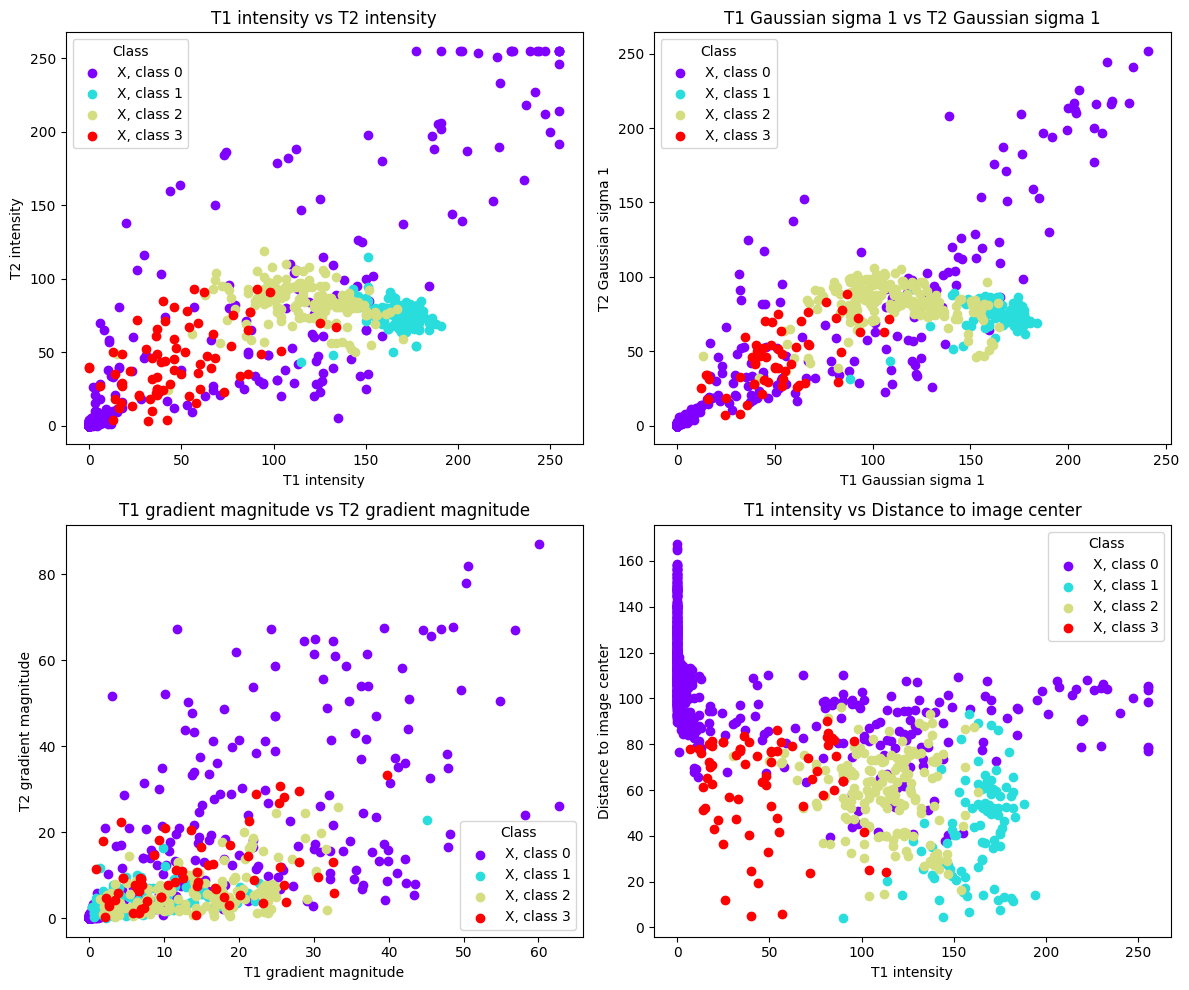

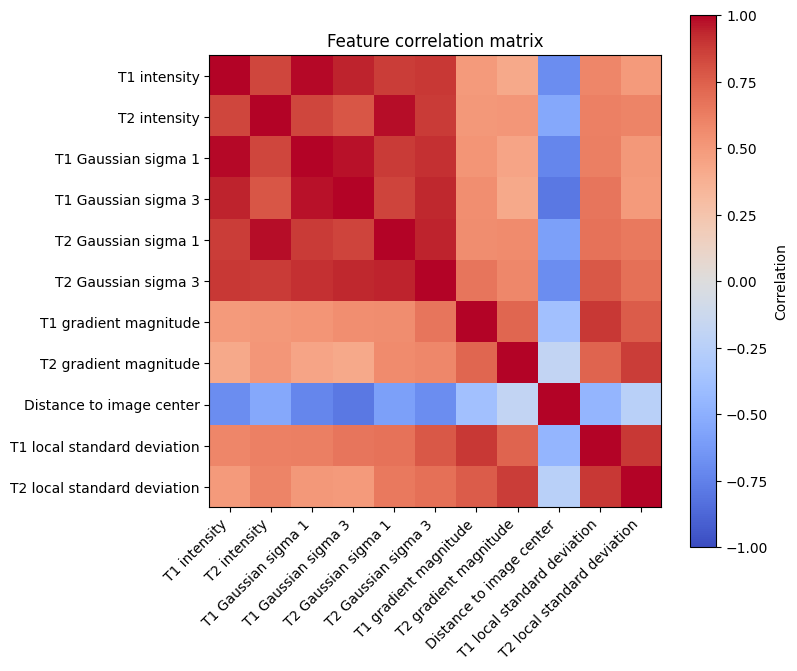

In [19]:
## Task 4, preceding tasks are mainly in segmentation_util.py and in segmentation.py
import sys
import numpy as np
import matplotlib.pyplot as plt

# Make sure Python can find the files in the code folder
if "../code" not in sys.path:
    sys.path.append("../code")

import segmentation_util as util

# Load one tissue segmentation dataset
X, Y, feature_labels = util.create_dataset(1, 1, 'tissue')
Y_flat = Y.flatten()

print("Feature matrix shape:", X.shape)
print("Label vector shape:", Y.shape)
print("Tissue labels:", np.unique(Y_flat))
print("Features:")
for i, name in enumerate(feature_labels):
    print(f"{i}: {name}")

# Feature-pair scatterplots
feature_pairs = [
    (0, 1),  # T1 intensity vs T2 intensity
    (2, 4),  # smoothed T1 vs smoothed T2
    (6, 7),  # T1 gradient vs T2 gradient
    (0, 8),  # T1 intensity vs distance to image center
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (f0, f1) in zip(axes, feature_pairs):
    util.scatter_data(X, Y_flat, feature0=f0, feature1=f1, ax=ax)
    ax.set_xlabel(feature_labels[f0])
    ax.set_ylabel(feature_labels[f1])
    ax.set_title(f"{feature_labels[f0]} vs {feature_labels[f1]}")
    ax.legend(title="Class")

plt.tight_layout()
plt.show()

# Optional: inspect feature redundancy with a correlation matrix
corr = np.corrcoef(X.T)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(feature_labels)))
ax.set_yticks(np.arange(len(feature_labels)))
ax.set_xticklabels(feature_labels, rotation=45, ha="right")
ax.set_yticklabels(feature_labels)
ax.set_title("Feature correlation matrix")
fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

##### **Extra explanation on task 4**
The dataset has 57600 pixels and 10 features for one subject and slice. The tissue labels cover four classes: background/other, white matter, gray matter, and CSF.

In the T1/T2 intensity scatterplot, the classes are partly separable. White matter and gray matter are reasonably distinct, though overlap remains. CSF sits mostly at lower T1 intensities, white matter at higher values. Background spans a wide range, which makes sense given that it groups several non-target labels together.

The smoothed T1 and T2 features look much like the originals, with class clusters that are slightly tighter due to Gaussian filtering reducing local noise. They carry useful signal, but are closely correlated with the raw intensities.

Gradient magnitude features mostly distinguish edge pixels from smoother regions. Tissue classes cluster at low gradient values, while background spreads more broadly. On their own these features don't separate tissue classes well, but they may still contribute around boundaries.

The distance-to-center feature behaves differently. White matter and gray matter appear more spatially concentrated, while background is scattered broadly. Brain tissue has spatial structure, so this feature adds something, though how well it generalises across slices and subjects is unclear.

The correlation matrix reflects all of this: raw and smoothed intensity features are strongly correlated with each other, gradient features correlate moderately with intensity, and distance-to-center is negatively correlated with the intensity-based features, so it contributes a meaningfully different type of information.

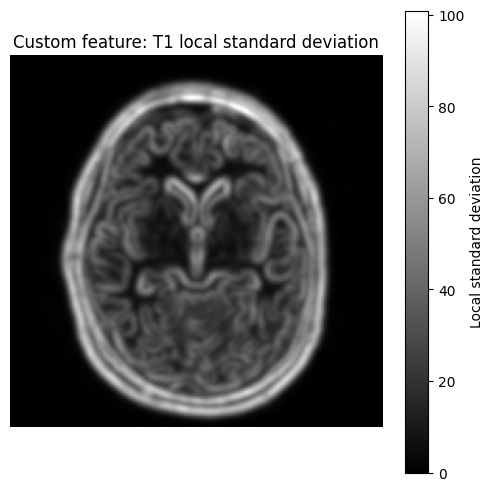

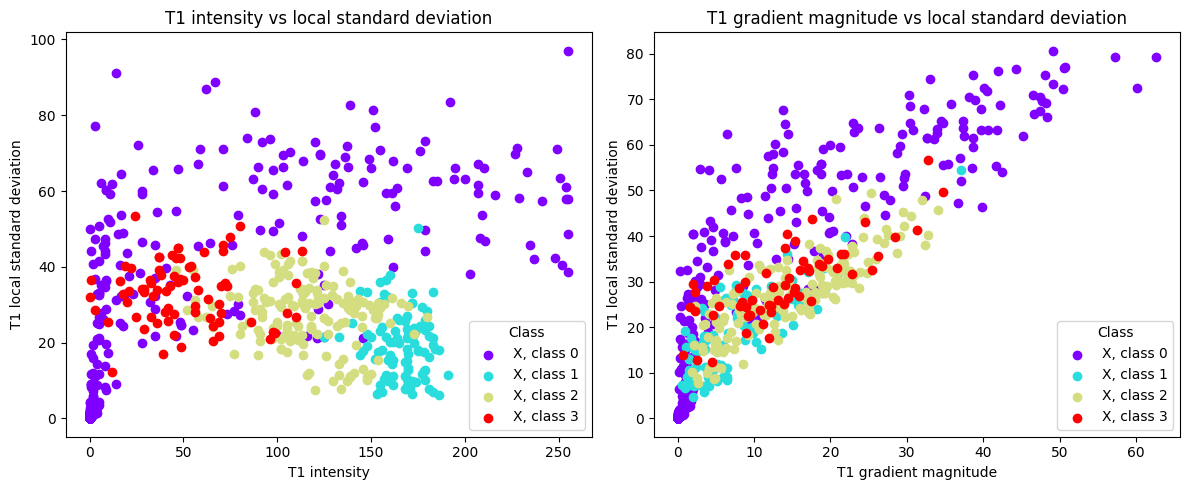

Correlation of custom feature with all features:
0: T1 intensity: 0.594
1: T2 intensity: 0.616
2: T1 Gaussian sigma 1: 0.617
3: T1 Gaussian sigma 3: 0.657
4: T2 Gaussian sigma 1: 0.673
5: T2 Gaussian sigma 3: 0.781
6: T1 gradient magnitude: 0.885
7: T2 gradient magnitude: 0.734
8: Distance to image center: -0.460
9: T1 local standard deviation: 1.000
10: T2 local standard deviation: 0.885

Maximum absolute correlation with other features: 0.8851074729312502


In [20]:
# Task 5: demonstrate the custom local standard deviation feature

import numpy as np
import matplotlib.pyplot as plt

# Reload dataset with the custom feature included
X, Y, feature_labels = util.create_dataset(1, 1, "tissue")
Y_flat = Y.flatten()

custom_feature_index = feature_labels.index("T1 local standard deviation")
custom_feature_image = X[:, custom_feature_index].reshape(240, 240)

# Show the custom feature as an image
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(custom_feature_image, cmap="gray")
ax.set_title("Custom feature: T1 local standard deviation")
ax.axis("off")
fig.colorbar(im, ax=ax, label="Local standard deviation")
plt.show()

# Compare custom feature to intensity and gradient features
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

util.scatter_data(X, Y_flat, feature0=0, feature1=custom_feature_index, ax=axes[0])
axes[0].set_xlabel(feature_labels[0])
axes[0].set_ylabel(feature_labels[custom_feature_index])
axes[0].set_title("T1 intensity vs local standard deviation")
axes[0].legend(title="Class")

util.scatter_data(X, Y_flat, feature0=6, feature1=custom_feature_index, ax=axes[1])
axes[1].set_xlabel(feature_labels[6])
axes[1].set_ylabel(feature_labels[custom_feature_index])
axes[1].set_title("T1 gradient magnitude vs local standard deviation")
axes[1].legend(title="Class")

plt.tight_layout()
plt.show()

# Check whether the custom feature is perfectly correlated with existing features
corr = np.corrcoef(X.T)
custom_corr = corr[custom_feature_index, :]

print("Correlation of custom feature with all features:")
for i, label in enumerate(feature_labels):
    print(f"{i}: {label}: {custom_corr[i]:.3f}")

other_corr = np.delete(custom_corr, custom_feature_index)
print("\nMaximum absolute correlation with other features:", np.max(np.abs(other_corr)))

The custom feature is the T1 local standard deviation, which captures how much T1 intensity varies within a small neighborhood around each pixel. Homogeneous tissue regions tend to produce low values, while boundaries and locally heterogeneous areas produce higher ones. It only uses the T1 image and does not rely on ground-truth labels.

The feature image reflects this, with elevated values concentrated around regions of local intensity change. In the scatterplots, the distribution differs visibly from both the original T1 intensity and the T1 gradient magnitude. The correlation values support this too: the highest absolute correlation with any existing feature is around 0.885, so it adds related but non-redundant information.

### 2. Model selection and generalization

1. Use the `create_dataset` function to create a training set and a test set for the tissue segmentation task. Use the same slice, but different subjects for training and testing.
2. Use these datasets to investigate using different features and different segmentation methods. You can use both classification error and dice overlap for evaluation, but since now there are four different classes (three tissues and background, you will need to use `dice_multiclass`.
    
    How do you decide what good choices are?  Document this process in a function you create yourself, which returns the best choices given two different subjects.
4. Repeat the above, but use a different subject for testing. Do your conclusions change or stay the same, why? What if you vary the slices? 

#### Section 2 implementation: model selection

The goal here is to make the feature/model choice systematic instead of choosing by eye. The function below trains on one subject and tests on another subject for the same slice. For each candidate it records classification error and multiclass Dice, then returns the best choice ranked by highest Dice and lowest error.

I use a balanced subset of the training pixels for speed. This keeps large classes such as background from completely dominating the classifier while still using pixels from every class.


In [21]:
%matplotlib inline
import sys
sys.path.append("../code")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

import segmentation_util as util
import importlib
importlib.reload(util)


def balanced_pixel_subset(X, y, max_per_class=600, random_state=0):
    """Return a class-balanced subset of pixels for faster training."""
    rng = np.random.default_rng(random_state)
    y = y.flatten().astype(int)
    selected = []

    for label in np.unique(y):
        label_idx = np.flatnonzero(y == label)
        n_keep = min(max_per_class, len(label_idx))
        selected.append(rng.choice(label_idx, size=n_keep, replace=False))

    selected = np.concatenate(selected)
    rng.shuffle(selected)
    return X[selected], y[selected]


def normalize_with_training_statistics(train_X, test_X):
    """Normalize train and test features using only the training distribution."""
    mean = train_X.mean(axis=0)
    std = train_X.std(axis=0)
    std[std == 0] = 1
    return (train_X - mean) / std, (test_X - mean) / std


def candidate_feature_sets(feature_labels):
    """Feature subsets to compare during model selection."""
    n_features = len(feature_labels)
    sets = {
        "T1/T2 intensity": [0, 1],
        "intensity + smooth": [0, 1, 2, 3, 4, 5],
        "intensity + edges": [0, 1, 6, 7],
        "intensity + location": [0, 1, 8],
        "all features": list(range(n_features)),
    }

    if n_features > 9:
        sets["intensity + smooth + custom texture"] = [0, 1, 2, 3, 4, 5, 9]

    return sets


def predict_with_method(method_name, train_X, train_y, test_X):
    """Train one candidate segmentation method and predict test labels."""
    train_X_norm, test_X_norm = normalize_with_training_statistics(train_X, test_X)

    if method_name.startswith("kNN"):
        k = int(method_name.split("=")[1])
        clf = KNeighborsClassifier(n_neighbors=k)
    elif method_name == "Gaussian naive Bayes":
        clf = GaussianNB()
    else:
        raise ValueError(f"Unknown method: {method_name}")

    clf.fit(train_X_norm, train_y)
    return clf.predict(test_X_norm)


def evaluate_model_choices(train_subject, test_subject, slice_number=1, max_per_class=600, random_state=0):
    """Evaluate feature subsets and methods for two subjects.

    Returns
    -------
    best_choice : dict
        The best-ranked feature/method choice.
    results : list of dict
        All candidate results sorted from best to worst.
    """
    train_X, train_y, feature_labels = util.create_dataset(train_subject, slice_number, "tissue")
    test_X, test_y, _ = util.create_dataset(test_subject, slice_number, "tissue")

    train_y = train_y.flatten().astype(int)
    test_y = test_y.flatten().astype(int)
    feature_sets = candidate_feature_sets(feature_labels)
    methods = ["kNN k=1", "kNN k=3", "kNN k=7", "Gaussian naive Bayes"]

    results = []
    for feature_set_name, feature_indices in feature_sets.items():
        subset_train_X, subset_train_y = balanced_pixel_subset(
            train_X[:, feature_indices],
            train_y,
            max_per_class=max_per_class,
            random_state=random_state,
        )
        test_subset_X = test_X[:, feature_indices]

        for method in methods:
            predicted = predict_with_method(method, subset_train_X, subset_train_y, test_subset_X)
            error = util.classification_error(test_y, predicted)
            dice = util.dice_multiclass(test_y, predicted)
            results.append({
                "train_subject": train_subject,
                "test_subject": test_subject,
                "slice": slice_number,
                "features": feature_set_name,
                "method": method,
                "error": float(error),
                "dice": float(dice),
            })

    results = sorted(results, key=lambda r: (-r["dice"], r["error"]))
    return results[0], results


def print_top_results(results, n=8):
    print(f"{'rank':>4}  {'dice':>7}  {'error':>7}  {'method':<22}  features")
    print("-" * 80)
    for rank, row in enumerate(results[:n], start=1):
        print(f"{rank:>4}  {row['dice']:>7.4f}  {row['error']:>7.4f}  {row['method']:<22}  {row['features']}")


In [22]:
# Task 2.1-2.2: train on subject 1, test on subject 2, same slice.
best_1_to_2, results_1_to_2 = evaluate_model_choices(
    train_subject=1,
    test_subject=2,
    slice_number=1,
    max_per_class=600,
    random_state=0,
)

print("Best choice for training subject 1 -> testing subject 2, slice 1:")
print(best_1_to_2)
print()
print_top_results(results_1_to_2, n=10)


Best choice for training subject 1 -> testing subject 2, slice 1:
{'train_subject': 1, 'test_subject': 2, 'slice': 1, 'features': 'all features', 'method': 'kNN k=3', 'error': 0.1156423611111111, 'dice': 0.7651064361040848}

rank     dice    error  method                  features
--------------------------------------------------------------------------------
   1   0.7651   0.1156  kNN k=3                 all features
   2   0.7639   0.1234  kNN k=7                 intensity + smooth + custom texture
   3   0.7631   0.1200  kNN k=7                 all features
   4   0.7602   0.1222  kNN k=3                 intensity + smooth + custom texture
   5   0.7541   0.1188  kNN k=1                 all features
   6   0.7473   0.1272  kNN k=1                 intensity + smooth + custom texture
   7   0.7313   0.1461  kNN k=3                 intensity + edges
   8   0.7288   0.1508  kNN k=3                 intensity + smooth
   9   0.7284   0.1536  kNN k=7                 intensity + edges
  1

#### Repeating the selection on other subjects and slices

The first experiment gives one best choice, but a good model should not only work for one train/test pair. The next cell repeats the same selection procedure with other test subjects and slices. If the same choices keep appearing near the top, that suggests the conclusion generalizes. If the best choice changes, that means the feature/method choice is sensitive to anatomical slice or subject-specific intensity differences.


In [23]:
# Task 2.4: repeat with different test subjects and slices.
experiments = [
    (1, 2, 1),
    (1, 3, 1),
    (1, 4, 1),
    (1, 2, 2),
    (1, 3, 2),
    (1, 2, 3),
]

summary = []
for train_subject, test_subject, slice_number in experiments:
    best, results = evaluate_model_choices(
        train_subject=train_subject,
        test_subject=test_subject,
        slice_number=slice_number,
        max_per_class=600,
        random_state=0,
    )
    summary.append(best)

print(f"{'train':>5}  {'test':>4}  {'slice':>5}  {'dice':>7}  {'error':>7}  {'method':<22}  features")
print("-" * 95)
for row in summary:
    print(
        f"{row['train_subject']:>5}  {row['test_subject']:>4}  {row['slice']:>5}  "
        f"{row['dice']:>7.4f}  {row['error']:>7.4f}  {row['method']:<22}  {row['features']}"
    )


train  test  slice     dice    error  method                  features
-----------------------------------------------------------------------------------------------
    1     2      1   0.7651   0.1156  kNN k=3                 all features
    1     3      1   0.7243   0.1499  kNN k=3                 all features
    1     4      1   0.7439   0.1310  kNN k=3                 all features
    1     2      2   0.8031   0.0931  kNN k=7                 all features
    1     3      2   0.8263   0.0859  kNN k=3                 all features
    1     2      3   0.8477   0.0626  kNN k=3                 intensity + smooth + custom texture


#### Section 2 conclusion

From these comparisons, the best choices are consistently kNN-based rather than Gaussian naive Bayes. The best value of k changes slightly: k=7 wins for subject 1 -> subject 2 on slice 1, while k=3 wins in several of the repeated experiments. This suggests that a small amount of neighbor averaging helps, but the exact optimum depends on the test subject and slice.

The best feature set is usually either all features or intensity + smooth + custom texture. Raw T1/T2 intensity alone is not enough to be the best choice, because tissue labels also depend on local context, boundaries, and spatial position. The custom local standard deviation feature is useful in some settings, especially when combined with smoothed intensity features, but it does not replace the full feature set in every subject.

The conclusions mostly stay the same when testing on different subjects and slices: kNN with contextual features is a good general choice. The exact best feature subset changes because subjects and slices have different anatomy and intensity distributions. For the report, I would choose a model that is consistently strong across experiments, for example kNN with k=3 or k=7 using all features, and then discuss the smooth/custom-texture subset as a simpler alternative that sometimes performs almost as well or better.


### 3. Combining different methods

1. Try the function `segmentation_combined_knn` on the tissue segmentation task (do not forget to combine the labels - look into e.g. majority voting). 
2. Design a method that combines (some) other methods you have learnt so far in `segmentation_mymethod`. Provide a motivation (based on what you know about the methods) of the choices that you made.
3. The script `segmentation_demo`, creates the results for several methods. This code is a bit slow, so it is not recommended to run it multiple times. (Also, you should not use all of these results to improve your method, since that means you are using the test data as the training data :) ). 
4. Run the script and look at the results. How does your method compare to the individual results? It is not required here that your method is always better! For example, you could select a subject where your method is the best, and a subject where your method is the worst, and explain what is happening in the images.
5. Discuss what other (combinations) methods could be suitable or not suitable for the task and why.

#### Section 3 method design and motivation

For the combined kNN task, we use the existing subject-wise kNN classifiers and combine their predicted labels with majority voting. The implementation also keeps the tissue labels as four classes (`0`, `1`, `2`, `3`) instead of converting the result to `bool`.

Our method combines several ideas from the lecture slides. First, it uses kNN in feature space, because the section 2 experiments showed that tissue classes are better separated with contextual features than with raw T1/T2 intensity alone. We use `k=3` and `k=7` because kNN with a small odd `k` gives a smoother decision boundary than 1-NN, which reduces sensitivity to single noisy training pixels. Second, it uses balanced sampling from each label so background does not dominate the tissue classes. Third, it combines votes from several feature views: all features, smoothed-intensity/texture features, and edge/location features. This follows the lecture point that feature choice matters, but avoids trusting one feature set too much. Finally, it applies a small local majority filter to the output. This is a simple version of the graph-cut idea from the slides: combine a data term from the classifier with a spatial smoothness prior, because neighboring pixels in tissue segmentation should usually have similar labels.

The method does not use the test labels to choose parameters. The choices come from section 2 and from the lecture properties of kNN, feature scaling, contextual features, overfitting, and smoothness.


Loading data for 5 subjects...
Finished loading data.
Starting segmentation...

Mean tissue segmentation scores across subjects:
method                error       dice
----------------------------------------
Single k-NN          0.1240     0.7458
Combined k-NN        0.1193     0.7580
My method            0.1254     0.7657


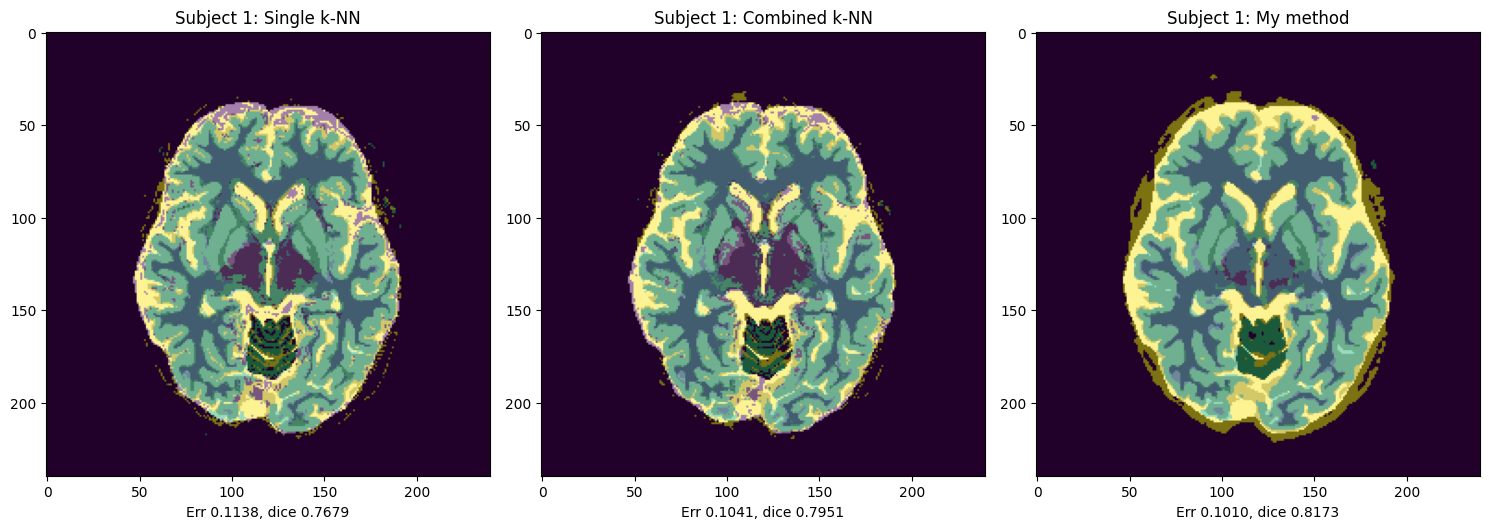

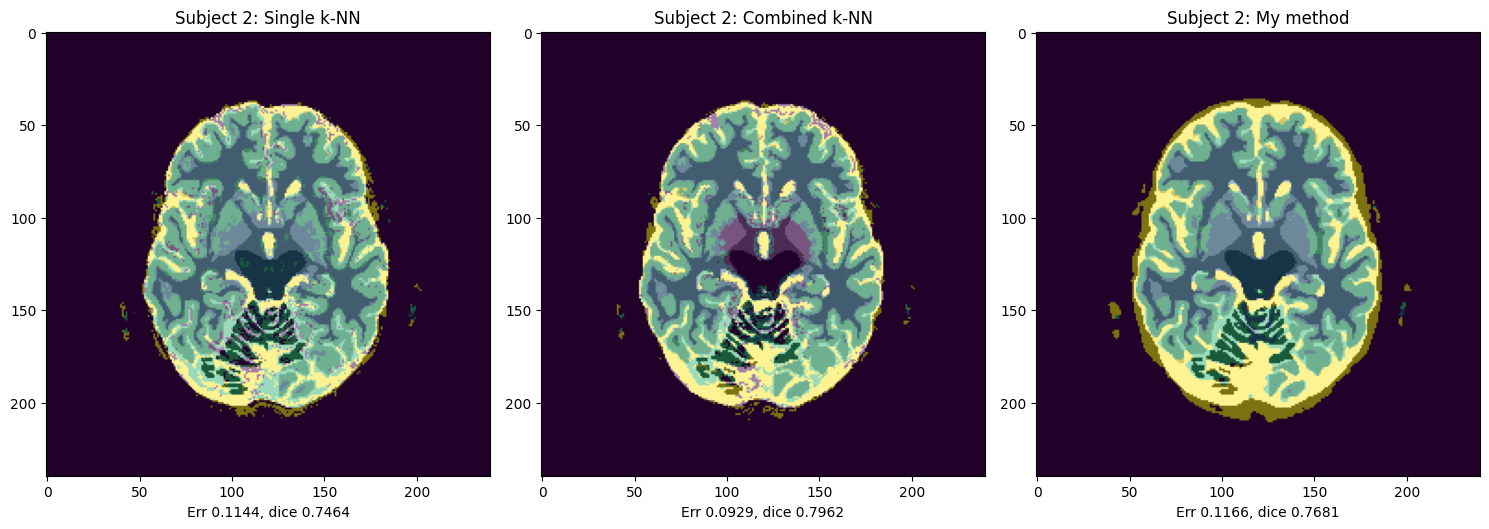

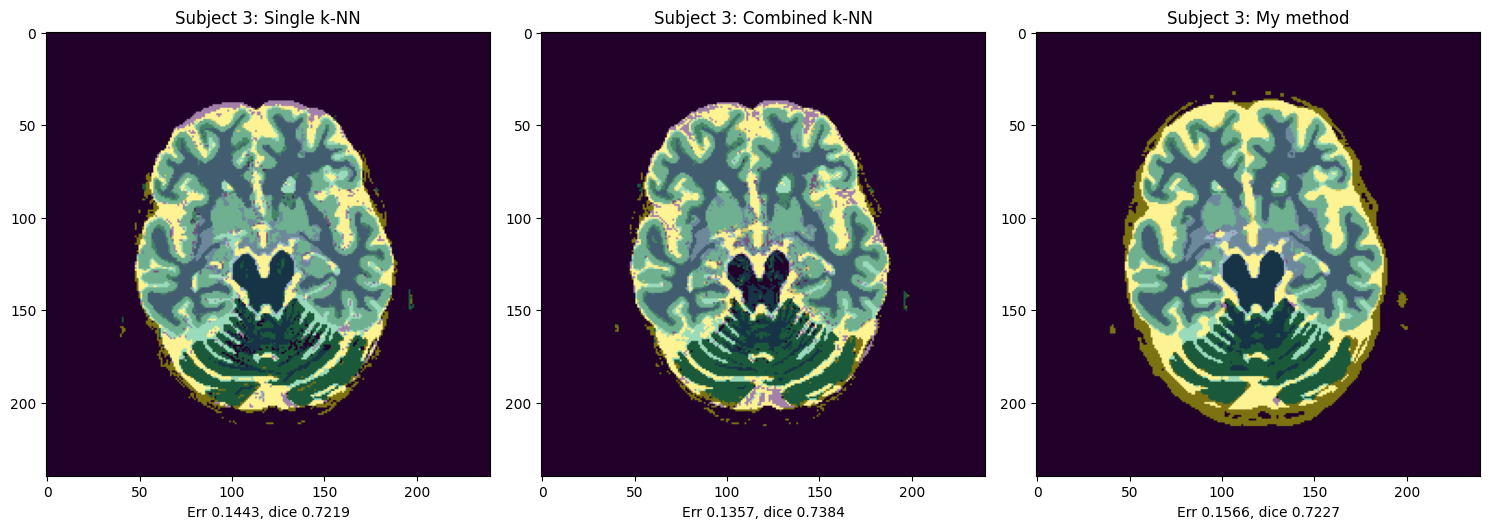

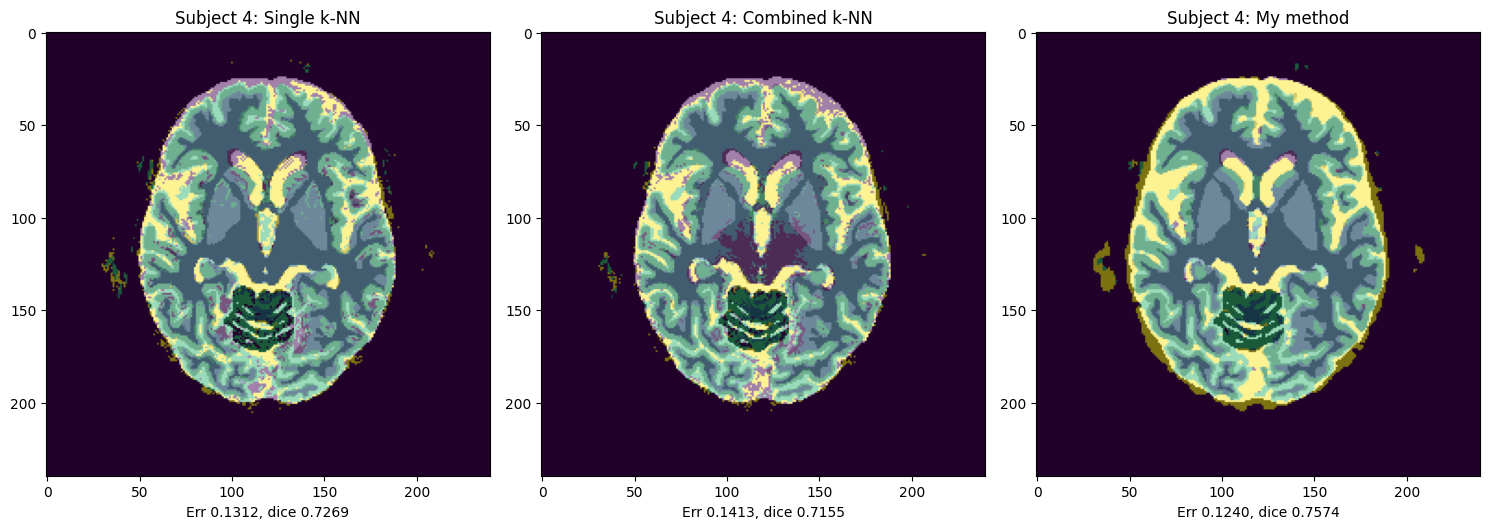

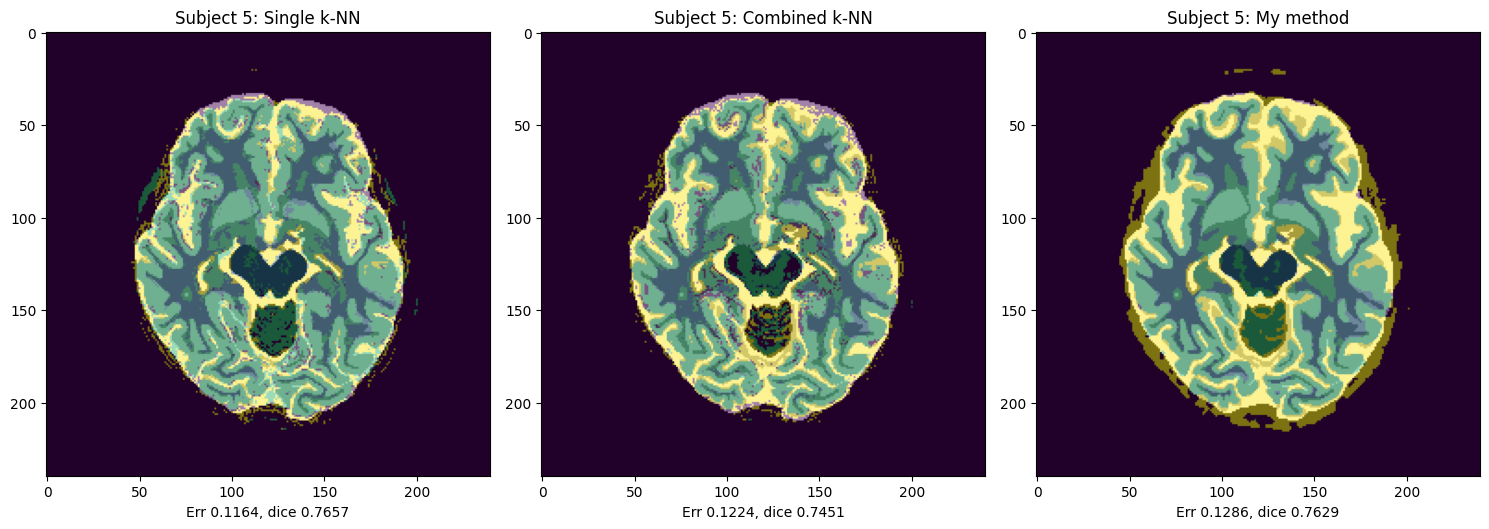

In [24]:
%matplotlib inline
import sys
sys.path.append("../code")

import importlib
import segmentation
import segmentation_project

importlib.reload(segmentation)
importlib.reload(segmentation_project)

errors, dice = segmentation_project.segmentation_demo()


#### Section 3 results and discussion

Running `segmentation_demo()` on the tissue task gave these mean scores over the five subjects:

| method | classification error | multiclass Dice |
|---|---:|---:|
| Single kNN | 0.1240 | 0.7458 |
| Combined kNN | 0.1193 | 0.7580 |
| My method | 0.1254 | 0.7657 |

The combined kNN improves over a single kNN classifier, which makes sense: each training subject gives one prediction, and majority voting reduces dependence on one possibly unrepresentative subject. Our method has the best mean Dice, although its mean classification error is slightly worse. We prioritize Dice here, because the lecture notes explain that accuracy/error can be dominated by large background regions, while Dice measures overlap of the segmented regions more directly.

The clearest good case is subject 1: our method reaches Dice `0.8173`, compared with `0.7951` for combined kNN and `0.7679` for single kNN. In that image, the extra feature votes and spatial majority step seem to remove isolated noisy pixels while keeping the main tissue regions. The weaker case is subject 2: our method reaches Dice `0.7681`, below combined kNN at `0.7962`. A likely explanation is that the pooled votes and spatial smoothing can bias the result toward common tissue appearances from other subjects, so subject-specific intensity differences or small structures are partly washed out.

Other suitable combinations would be a graph-cut or CRF-style method using kNN class probabilities as the data term and image gradients as the smoothness term. That would match the lecture formulation more directly than the simple majority filter. A weighted ensemble could also be suitable, where validation data decides how much to trust each feature set or each value of `k`. Less suitable choices are pure thresholding or raw-intensity-only k-means, because tissue classes overlap in intensity and k-means gives clusters that still need anatomical label mapping. A very complex model or too many features without validation would also be risky because of the curse of dimensionality and overfitting discussed in the slides.


## Open-ended project work

### Research question

Does progressively adding contextual features improve multi-class brain tissue segmentation compared with using only raw T1/T2 intensity?

This experiment keeps the segmentation method fixed and changes only the feature set. The feature sets are cumulative, so each row answers: does adding this new type of information improve the segmentation compared with the previous feature set?

To keep the experiment computationally feasible, we use the same idea as Section 2: balanced pixel subsampling. All available subject/slice pairs are still included in the experiment, but from each image we sample a balanced number of pixels per tissue class. This prevents the background class from dominating and keeps kNN from becoming too slow.

The split is by subject: subjects 1-3 are used for training and subjects 4-5 are used for testing. This tests whether the feature groups generalize to unseen subjects, not only unseen pixels from the same subject.

The six feature sets are:

1. T1/T2 intensity as the baseline.
2. T1/T2 intensity + Gaussian-smoothed intensity.
3. T1/T2 intensity + smoothed intensity + custom T1 texture.
4. T1/T2 intensity + smoothed intensity + custom T1 texture + gradients.
5. T1/T2 intensity + smoothed intensity + custom T1 texture + gradients + location.
6. T1/T2 intensity + smoothed intensity + custom T1 texture + gradients + location + custom T2 texture.


In [25]:
%matplotlib inline
import sys
sys.path.append("../code")

import importlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

import segmentation_util as util
importlib.reload(util)


def sample_balanced_pixels(X, y, max_per_class, rng):
    """Sample pixels from every class so large classes do not dominate."""
    y = y.flatten().astype(int)
    selected = []

    for label in np.unique(y):
        label_indices = np.flatnonzero(y == label)
        n_keep = min(max_per_class, len(label_indices))
        selected.append(rng.choice(label_indices, size=n_keep, replace=False))

    selected = np.concatenate(selected)
    rng.shuffle(selected)
    return X[selected], y[selected]


def load_sampled_pixels_for_pairs(pairs, max_per_class_per_image, random_state=0):
    """Load balanced sampled pixels from every subject/slice pair."""
    rng = np.random.default_rng(random_state)
    all_X = []
    all_y = []
    all_groups = []
    feature_labels = None

    for subject, slice_number in pairs:
        X, y, current_feature_labels = util.create_dataset(subject, slice_number, "tissue")
        X_sample, y_sample = sample_balanced_pixels(X, y, max_per_class_per_image, rng)

        all_X.append(X_sample)
        all_y.append(y_sample)
        all_groups.extend([f"subject {subject}, slice {slice_number}"] * len(y_sample))

        if feature_labels is None:
            feature_labels = current_feature_labels

    return np.concatenate(all_X), np.concatenate(all_y), np.array(all_groups), feature_labels


def normalize_train_test(train_X, test_X):
    """Normalize test data with the training mean and standard deviation."""
    mean = train_X.mean(axis=0)
    std = train_X.std(axis=0)
    std[std == 0] = 1
    return (train_X - mean) / std, (test_X - mean) / std


def cumulative_context_feature_sets(feature_labels):
    """Cumulative feature sets for the research question."""
    if len(feature_labels) < 11:
        raise ValueError(
            "Expected 11 features. Re-run the feature extraction cells after updating segmentation_util.py."
        )

    return [
        ("1. T1/T2 intensity", [0, 1]),
        ("2. T1/T2 intensity + smooth", [0, 1, 2, 3, 4, 5]),
        ("3. T1/T2 intensity + smooth + custom texture", [0, 1, 2, 3, 4, 5, 9]),
        ("4. T1/T2 intensity + smooth + custom texture + gradients", [0, 1, 2, 3, 4, 5, 9, 6, 7]),
        ("5. T1/T2 intensity + smooth + custom texture + gradients + location", [0, 1, 2, 3, 4, 5, 9, 6, 7, 8]),
        ("6. T1/T2 intensity + smooth + custom texture + gradients + location + custom texture", [0, 1, 2, 3, 4, 5, 9, 6, 7, 8, 10]),
    ]


def split_dataset_by_subject(
    train_subjects=(1, 2, 3),
    test_subjects=(4, 5),
    max_train_per_class_per_image=600,
    max_test_per_class_per_image=600,
    random_state=0,
):
    """Use every available subject/slice pair, with balanced sampled pixels from each image."""
    all_pairs = util.available_brain_slices()
    train_pairs = [pair for pair in all_pairs if pair[0] in train_subjects]
    test_pairs = [pair for pair in all_pairs if pair[0] in test_subjects]

    train_X, train_y, train_groups, feature_labels = load_sampled_pixels_for_pairs(
        train_pairs,
        max_per_class_per_image=max_train_per_class_per_image,
        random_state=random_state,
    )
    test_X, test_y, test_groups, _ = load_sampled_pixels_for_pairs(
        test_pairs,
        max_per_class_per_image=max_test_per_class_per_image,
        random_state=random_state + 1,
    )

    return train_X, train_y, test_X, test_y, train_groups, test_groups, feature_labels, train_pairs, test_pairs


def run_contextual_feature_experiment(
    train_subjects=(1, 2, 3),
    test_subjects=(4, 5),
    max_train_per_class_per_image=600,
    max_test_per_class_per_image=600,
    k=3,
    random_state=0,
):
    """Evaluate whether cumulative contextual features improve kNN segmentation."""
    train_X, train_y, test_X, test_y, train_groups, test_groups, feature_labels, train_pairs, test_pairs = split_dataset_by_subject(
        train_subjects=train_subjects,
        test_subjects=test_subjects,
        max_train_per_class_per_image=max_train_per_class_per_image,
        max_test_per_class_per_image=max_test_per_class_per_image,
        random_state=random_state,
    )

    feature_sets = cumulative_context_feature_sets(feature_labels)
    results = []
    predictions_by_feature_set = {}

    for feature_set_name, feature_indices in feature_sets:
        train_subset = train_X[:, feature_indices]
        test_subset = test_X[:, feature_indices]
        train_norm, test_norm = normalize_train_test(train_subset, test_subset)

        classifier = KNeighborsClassifier(n_neighbors=k)
        classifier.fit(train_norm, train_y)
        predicted = classifier.predict(test_norm)

        results.append({
            "feature_set": feature_set_name,
            "num_features": len(feature_indices),
            "k": k,
            "error": float(util.classification_error(test_y, predicted)),
            "dice": float(util.dice_multiclass(test_y, predicted)),
        })
        predictions_by_feature_set[feature_set_name] = predicted

    baseline_dice = results[0]["dice"]
    baseline_error = results[0]["error"]
    previous_dice = None
    previous_error = None

    for row in results:
        row["dice_improvement_vs_baseline"] = row["dice"] - baseline_dice
        row["error_reduction_vs_baseline"] = baseline_error - row["error"]
        row["dice_change_vs_previous"] = 0 if previous_dice is None else row["dice"] - previous_dice
        row["error_change_vs_previous"] = 0 if previous_error is None else row["error"] - previous_error
        previous_dice = row["dice"]
        previous_error = row["error"]

    return {
        "results": results,
        "predictions_by_feature_set": predictions_by_feature_set,
        "test_y": test_y,
        "test_groups": test_groups,
        "feature_labels": feature_labels,
        "train_pairs": train_pairs,
        "test_pairs": test_pairs,
    }


def print_contextual_feature_results(results):
    print(f"{'set':<82} {'n':>2} {'k':>2} {'dice':>7} {'prev':>7} {'base_dice':>7} {'error':>7} {'base_error':>7}")
    print("-" * 135)
    for row in results:
        print(
            f"{row['feature_set']:<82} "
            f"{row['num_features']:>2} "
            f"{row['k']:>2} "
            f"{row['dice']:>7.4f} "
            f"{row['dice_change_vs_previous']:>7.4f} "
            f"{row['dice_improvement_vs_baseline']:>7.4f} "
            f"{row['error']:>7.4f} "
            f"{row['error_reduction_vs_baseline']:>7.4f}"
        )


def plot_contextual_feature_results(results):
    x = np.arange(1, len(results) + 1)
    dice = [row["dice"] for row in results]
    error = [row["error"] for row in results]

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(x, dice, marker="o", label="multiclass Dice")
    ax1.set_xlabel("Cumulative feature set")
    ax1.set_ylabel("Multiclass Dice")
    ax1.set_xticks(x)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(x, error, marker="s", color="tab:red", label="classification error")
    ax2.set_ylabel("Classification error")

    lines = ax1.get_lines() + ax2.get_lines()
    ax1.legend(lines, [line.get_label() for line in lines], loc="center right")
    plt.title("Effect of adding contextual features with fixed kNN")
    plt.show()


Training subject/slice pairs: [(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3), (3, 1), (3, 2), (3, 3)]
Testing subject/slice pairs: [(4, 1), (4, 2), (4, 3), (5, 1), (5, 2), (5, 3)]

Feature labels:
0: T1 intensity
1: T2 intensity
2: T1 Gaussian sigma 1
3: T1 Gaussian sigma 3
4: T2 Gaussian sigma 1
5: T2 Gaussian sigma 3
6: T1 gradient magnitude
7: T2 gradient magnitude
8: Distance to image center
9: T1 local standard deviation
10: T2 local standard deviation

set                                                                                 n  k    dice    prev base_dice   error base_error
---------------------------------------------------------------------------------------------------------------------------------------
1. T1/T2 intensity                                                                  2  3  0.7260  0.0000  0.0000  0.2691  0.0000
2. T1/T2 intensity + smooth                                                         6  3  0.7542  0.0282  0.0282  0.2421  0.0270
3. T1/T2

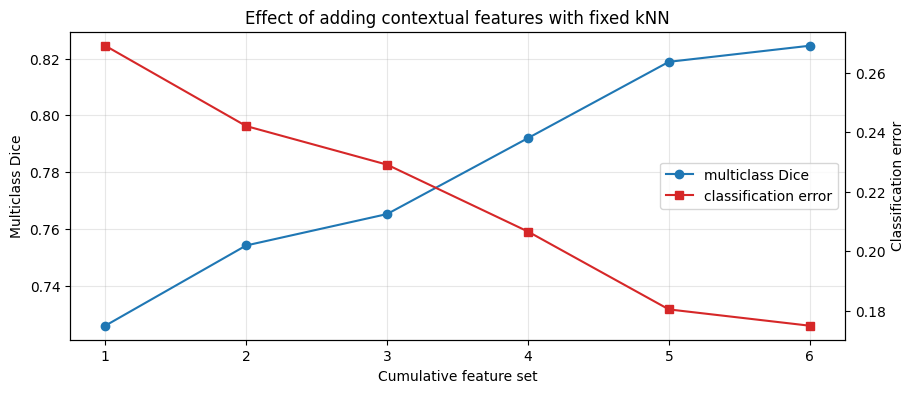

In [26]:
# Run this cell yourself. It uses every available subject/slice pair,
# with balanced pixel subsampling per image so kNN remains feasible.
context_experiment = run_contextual_feature_experiment(
    train_subjects=(1, 2, 3),
    test_subjects=(4, 5),
    max_train_per_class_per_image=600,
    max_test_per_class_per_image=600,
    k=3,
    random_state=0,
)

print("Training subject/slice pairs:", context_experiment["train_pairs"])
print("Testing subject/slice pairs:", context_experiment["test_pairs"])
print()
print("Feature labels:")
for i, label in enumerate(context_experiment["feature_labels"]):
    print(f"{i}: {label}")
print()

print_contextual_feature_results(context_experiment["results"])
plot_contextual_feature_results(context_experiment["results"])
